# 3G - Ciclo de vida do Nino 3.4 em relacao ao DHW (P90/P95)

**Pergunta especifica.** Como o calor acumulado DHW se comporta nos eventos `forte_p90` e `super_p95`: antecede, acompanha ou ecoa a SSTA?

**Objetivo.** Posicionar o DHW no ciclo fisico e testar se ele mede severidade/duracao nas duas classes executivas da Fase 3.

**Justificativa.** Classes abaixo de P90 foram descartadas. O DHW nao define evento; ele resume a carga termica acumulada dos eventos que atingem a cauda quente local.

**Metodologia.** Composto SSTA x DHW alinhado ao pico para eventos >P90; DHW por fase; escalonamento DHW_max vs pico/duracao. **Area:** caixa Nino 3.4.

**Saidas.** `phase3G_eventos_dhw.csv`, `phase3G_composto_ssta_dhw.csv`, `phase3G_escalonamento.csv`, `phase3G_estado_atual.csv` + figuras.


[tabela] data\processed\parquet\statistics\phase3G_composto_ssta_dhw.csv
Pico composto do DHW C-week P90 ocorre +9 semanas em relacao ao pico da SSTA


C:\Users\thiag\AppData\Local\Temp\ipykernel_13932\1957737543.py:17: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  lines=ax1.get_lines()+ax2.get_lines(); ax1.legend(lines,[l.get_label() for l in lines],loc='upper left',fontsize=8)


[figura] data\processed\figures\fase3\phase3G_composto_ssta_dhw.png


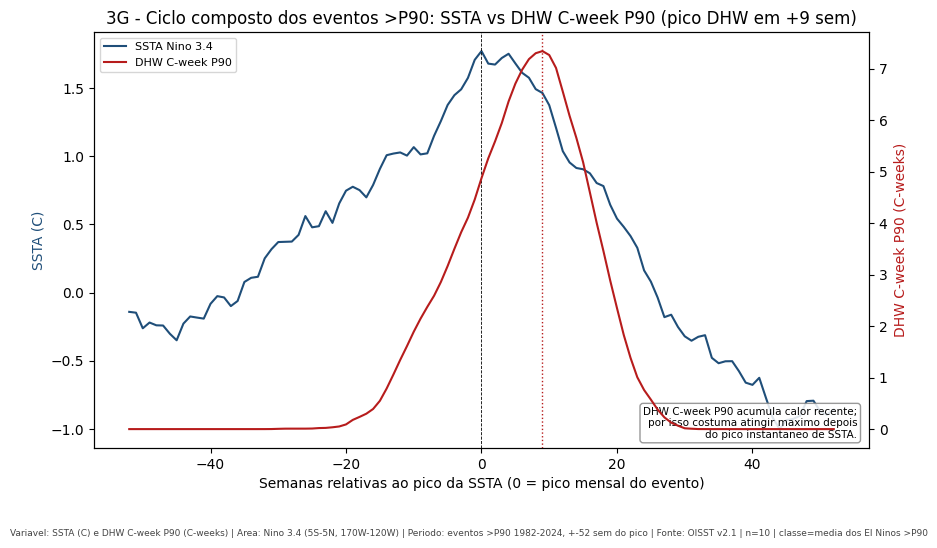

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_p90_p95(); ssta,dhw=w['nino34_ssta'],w['dhw_cweek_p90']; lags=list(range(-52,53))
def comp(series):
    mm=[]
    for _,e in ev.iterrows():
        i=series.index.get_indexer([e.peak_time],method='nearest')[0]; seg=series.iloc[max(0,i-52):i+53]
        rel=((seg.index-series.index[i]).days/7).round().astype(int); mm.append(pd.Series(seg.values,index=rel))
    return pd.DataFrame(mm).reindex(columns=lags).mean()
cp=pd.DataFrame({'ssta':comp(ssta),'dhw_cweek_p90':comp(dhw)}); u.save_table(cp.rename_axis('semana_rel_pico'),'phase3G_composto_ssta_dhw.csv')
lagpk=int(cp['dhw_cweek_p90'].idxmax()); print(f'Pico composto do DHW C-week P90 ocorre {lagpk:+d} semanas em relacao ao pico da SSTA')
fig,ax1=plt.subplots(figsize=(10,5.4)); ax1.plot(cp.index,cp['ssta'],color='#1f4e79',label='SSTA Nino 3.4'); ax1.set_ylabel('SSTA (C)',color='#1f4e79'); ax1.axvline(0,color='k',ls='--',lw=.6)
ax2=ax1.twinx(); ax2.plot(cp.index,cp['dhw_cweek_p90'],color='#b71c1c',label='DHW C-week P90'); ax2.set_ylabel('DHW C-week P90 (C-weeks)',color='#b71c1c'); ax2.axvline(lagpk,color='#b71c1c',ls=':',lw=1)
ax1.set_xlabel('Semanas relativas ao pico da SSTA (0 = pico mensal do evento)'); ax1.set_title(f'3G - Ciclo composto dos eventos >P90: SSTA vs DHW C-week P90 (pico DHW em {lagpk:+d} sem)')
lines=ax1.get_lines()+ax2.get_lines(); ax1.legend(lines,[l.get_label() for l in lines],loc='upper left',fontsize=8)
u.add_note(ax1,'DHW C-week P90 acumula calor recente;\npor isso costuma atingir maximo depois\ndo pico instantaneo de SSTA.',loc='lower right')
u.stamp_caption(fig,variavel='SSTA (C) e DHW C-week P90 (C-weeks)',area=u.CAIXAS['nino34'],periodo='eventos >P90 1982-2024, +-52 sem do pico',fonte='OISST v2.1',n=str(len(ev)),extra='classe=media dos El Ninos >P90')
u.save_fig(fig,'phase3G_composto_ssta_dhw.png'); plt.show()


In [2]:
rows=[]
for _,e in ev.iterrows():
    onset,peak,end=e.event_start,e.peak_time,e.event_end; meio=onset+(peak-onset)/2; seg=dhw.loc[onset:end]
    ipk=seg.idxmax() if seg.notna().any() else pd.NaT
    rows.append({'event_id':e.event_id,'classe':e.classe_p90_p95,'ssta_pico_c':round(e.peak_monthly_ssta_c,3),'duracao_meses':e.duration_months,
     'dhw_nascimento':round(float(dhw.asof(onset)),2),'dhw_meio_cresc':round(float(dhw.asof(meio)),2),'dhw_no_pico_ssta':round(float(dhw.asof(peak)),2),
     'dhw_maximo':round(float(seg.max()),2) if seg.notna().any() else np.nan,'defasagem_pico_dhw_sem':int(round((ipk-peak).days/7)) if pd.notna(ipk) else np.nan,'dhw_fim':round(float(dhw.asof(end)),2)})
met=pd.DataFrame(rows); u.save_table(met,'phase3G_eventos_dhw.csv',index=False); met


[tabela] data\processed\parquet\statistics\phase3G_eventos_dhw.csv


,event_id,classe,ssta_pico_c,duracao_meses,dhw_nascimento,dhw_meio_cresc,dhw_no_pico_ssta,dhw_maximo,defasagem_pico_dhw_sem,dhw_fim
0,el_nino_oisst_1982_1983,super_p95,2.213,11,0.0,0.96,9.67,13.40,6,4.05
1,el_nino_oisst_1986_1988,forte_p90,1.223,16,0.0,0.20,0.22,2.25,11,0.26
2,el_nino_oisst_1991_1992,super_p95,1.736,10,0.0,0.01,1.84,7.01,9,0.55
3,el_nino_oisst_1994_1995,forte_p90,1.192,5,0.0,0.00,0.01,0.73,5,0.73
4,el_nino_oisst_1997_1998,super_p95,2.166,11,0.0,3.77,11.48,13.00,10,7.90
5,el_nino_oisst_2002_2003,forte_p90,1.250,8,0.0,0.00,0.19,2.55,10,2.31
6,el_nino_oisst_2006_2007,forte_p90,1.128,5,0.0,0.00,0.00,0.30,4,0.30
7,el_nino_oisst_2009_2010,super_p95,1.719,10,0.0,0.00,1.80,6.68,8,3.46
8,el_nino_oisst_2014_2016,super_p95,2.448,19,0.0,0.00,14.70,18.29,9,13.74
9,el_nino_oisst_2023_2024,super_p95,2.007,12,0.0,0.22,7.22,10.49,7,5.39


[tabela] data\processed\parquet\statistics\phase3G_escalonamento.csv


[figura] data\processed\figures\fase3\phase3G_escalonamento.png


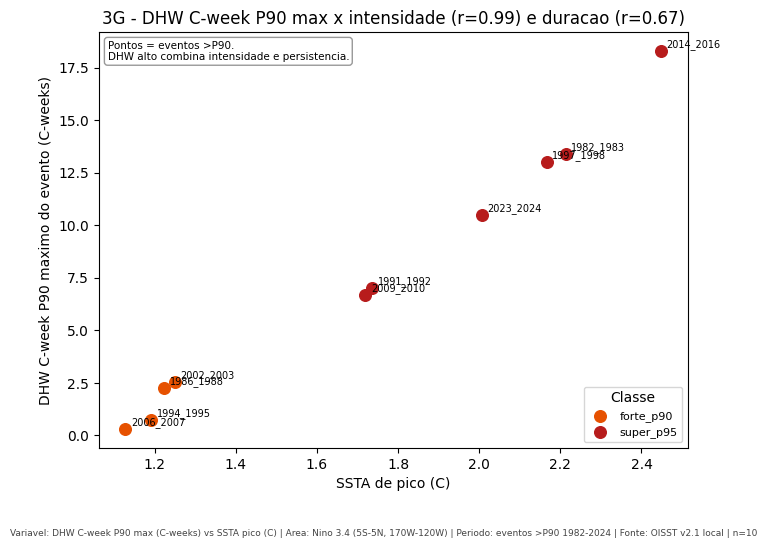

In [3]:
mm=met.dropna(subset=['dhw_maximo'])
ri=float(np.corrcoef(mm['dhw_maximo'],mm['ssta_pico_c'])[0,1]); rd=float(np.corrcoef(mm['dhw_maximo'],mm['duracao_meses'])[0,1])
u.save_table(pd.DataFrame([{'metrica_dhw':'dhw_cweek_p90','relacao':'dhw_max x ssta_pico','r':round(ri,3),'n':len(mm)},{'metrica_dhw':'dhw_cweek_p90','relacao':'dhw_max x duracao','r':round(rd,3),'n':len(mm)}]),'phase3G_escalonamento.csv',index=False)
cores={'super_p95':'#b71c1c','forte_p90':'#e65100'}
fig,ax=plt.subplots(figsize=(7.6,5.4))
for cls,g in mm.groupby('classe'): ax.scatter(g['ssta_pico_c'],g['dhw_maximo'],label=cls,color=cores.get(cls,'k'),s=70)
for _,r in mm.iterrows(): ax.annotate(r['event_id'].replace('el_nino_oisst_',''),(r['ssta_pico_c'],r['dhw_maximo']),fontsize=7,xytext=(4,3),textcoords='offset points')
ax.set_xlabel('SSTA de pico (C)'); ax.set_ylabel('DHW C-week P90 maximo do evento (C-weeks)'); ax.legend(fontsize=8,title='Classe')
ax.set_title(f'3G - DHW C-week P90 max x intensidade (r={ri:.2f}) e duracao (r={rd:.2f})')
u.add_note(ax,'Pontos = eventos >P90.\nDHW alto combina intensidade e persistencia.',loc='upper left')
u.stamp_caption(fig,variavel='DHW C-week P90 max (C-weeks) vs SSTA pico (C)',area=u.CAIXAS['nino34'],periodo='eventos >P90 1982-2024',fonte='OISST v2.1 local',n=str(len(mm)))
u.save_fig(fig,'phase3G_escalonamento.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3G_estado_atual.csv


[figura] data\processed\figures\fase3\phase3G_mapa_dhw_lon.png


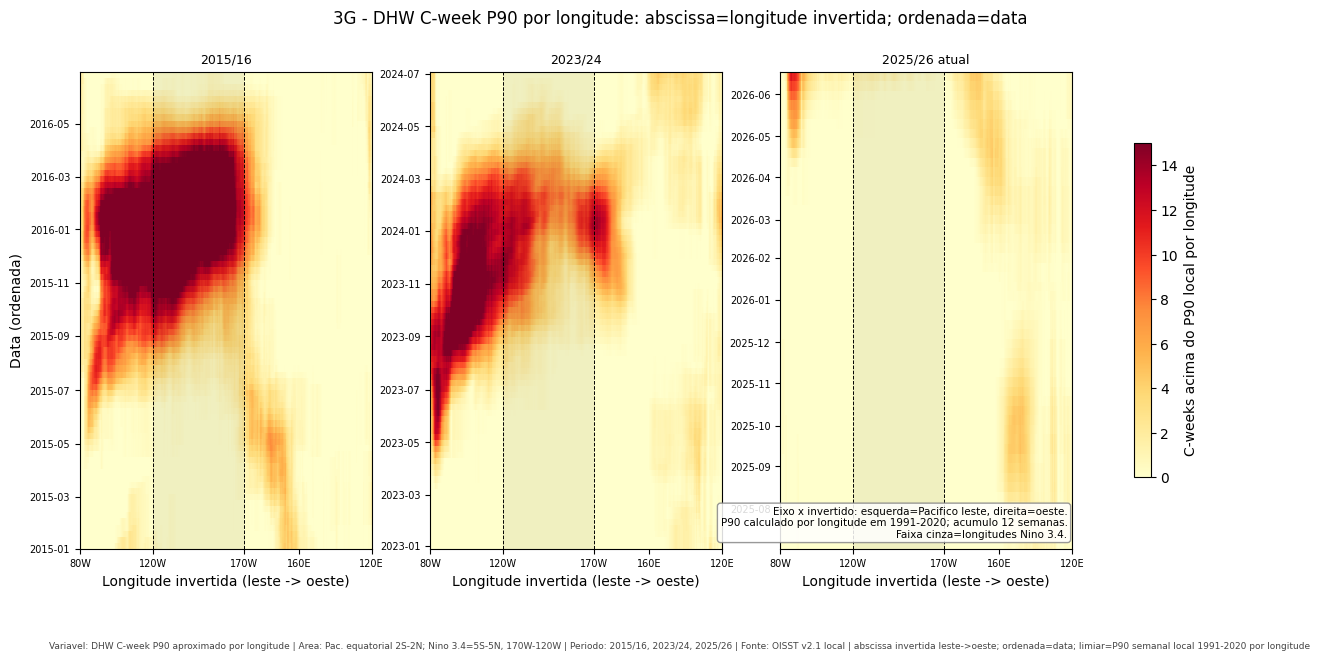

DHW C-week P90 lon max atual (jun/2026): 11.75


In [4]:
eq=u.load_eqband_weekly()
ref=eq.loc['1991-01-01':'2020-12-31']
p90_lon=ref.quantile(0.90)
exc=(eq-p90_lon).clip(lower=0)
dl=exc.rolling(12,min_periods=12).sum()
wins=[('2015-01-04','2016-06-26','2015/16'),('2023-01-01','2024-06-30','2023/24'),('2025-07-01',None,'2025/26 atual')]
fig,axes=plt.subplots(1,3,figsize=(16,6.2)); lon=eq.columns.values
for ax,(t0,t1,tt) in zip(axes,wins):
    seg=dl.loc[t0:t1] if t1 else dl.loc[t0:]; pc=ax.pcolormesh(lon,seg.index,seg.values,cmap='YlOrRd',vmin=0,vmax=15,shading='auto')
    u.add_nino34_lon_band(ax,label=False); u.format_lon_axis(ax, xlabel='Longitude invertida (leste -> oeste)')
    ax.set_title(tt,fontsize=9); ax.tick_params(labelsize=7)
axes[0].set_ylabel('Data (ordenada)')
fig.suptitle('3G - DHW C-week P90 por longitude: abscissa=longitude invertida; ordenada=data')
fig.colorbar(pc,ax=axes,label='C-weeks acima do P90 local por longitude',shrink=.7)
u.add_note(axes[-1],'Eixo x invertido: esquerda=Pacifico leste, direita=oeste.\nP90 calculado por longitude em 1991-2020; acumulo 12 semanas.\nFaixa cinza=longitudes Nino 3.4.',loc='lower right')
u.stamp_caption(fig,variavel='DHW C-week P90 aproximado por longitude',area='Pac. equatorial 2S-2N; Nino 3.4=5S-5N, 170W-120W',periodo='2015/16, 2023/24, 2025/26',fonte='OISST v2.1 local',extra='abscissa invertida leste->oeste; ordenada=data; limiar=P90 semanal local 1991-2020 por longitude')
at=dl.loc['2026-06-01':].max().max(); u.save_table(pd.DataFrame([{'dhw_cweek_p90_lon_max_atual_cweeks':round(float(at),2)}]),'phase3G_estado_atual.csv',index=False)
u.save_fig(fig,'phase3G_mapa_dhw_lon.png'); plt.show(); print('DHW C-week P90 lon max atual (jun/2026):',round(float(at),2))


**Leitura do 3G.** O DHW e **integrador**: pica depois do pico da SSTA, logo nao e precursor longo. Nos eventos elegiveis `forte_p90` e `super_p95`, ele escala com intensidade e duracao, funcionando como severidade acumulada/memoria curta. Classes abaixo de P90 foram descartadas desta leitura.
